In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# DPO's foundation: solve the finite KL optimum

Day 17 · Chapter 11. CPU, authored synthetic data, no downloads. Predict before each reference, change one declared variable, and interpret the result. Code is complete so the notebook runs from beginning to end. Completing its execution is material verification, not an assessment of learner mastery.

[Canonical chapter](../../book/chapters/11-direct-preference-optimization.md)


In [2]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / "src" / "dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
blue, orange, green = "#356a9b", "#b97139", "#3d8268"



## Exercise 1: probability movement

A reference favors a familiar answer. Reward favors another. Predict what happens as beta approaches zero or becomes large. Then inspect the exact optimizer rather than taking a noisy training run as the answer.


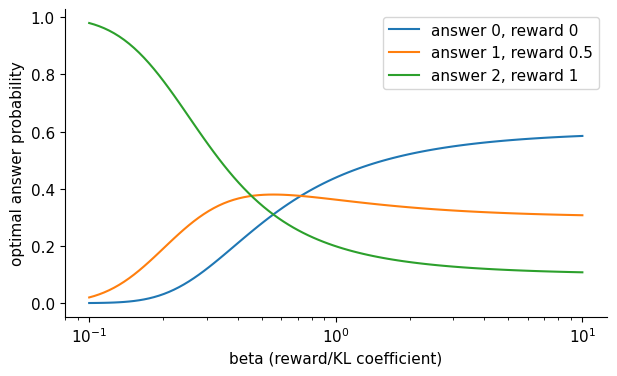

Reference probabilities [0.6, 0.3, 0.1]


In [3]:
from dongxi_llms.dpo_lab import optimal_policy
reference = torch.tensor([.6,.3,.1],dtype=torch.float64)
reward = torch.tensor([0.,.5,1.],dtype=torch.float64)
betas=torch.logspace(-1,1,100,dtype=torch.float64)
policies=torch.stack([optimal_policy(reference,reward,float(b)) for b in betas])
fig,ax=plt.subplots(figsize=(7,4))
for action in range(3):ax.plot(betas,policies[:,action],label=f"answer {action}, reward {reward[action]:g}")
ax.set(xscale="log",xlabel="beta (reward/KL coefficient)",ylabel="optimal answer probability");ax.legend();plt.show()
print("Reference probabilities",reference.tolist())


![Saved reference plot for 01 kl regularized optimum, figure 1](../figures/chapter-11/day-17-01_kl_regularized_optimum-01.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Read the figure:** larger beta moves the optimum toward the reference; smaller beta favors the highest reward. This is a fixed-reward comparison, not the initial DPO gradient's beta scaling.

## Exercise 2: prove stationarity numerically

At the optimum, reward minus beta times log-ratio-plus-one should be the same for every answer. Why is the shared constant allowed?


In [4]:
beta=.5
policy=optimal_policy(reference,reward,beta)
stationarity=reward-beta*(policy.log()-reference.log()+1)
torch.testing.assert_close(stationarity,stationarity.mean().expand_as(stationarity))
print({"policy":policy.tolist(),"stationarity":stationarity.tolist(),
       "KL":float((policy*(policy.log()-reference.log())).sum()),
       "objective":float((policy*reward).sum()-beta*(policy*(policy.log()-reference.log())).sum())})


{'policy': [0.2785010865613264, 0.37852222140287656, 0.34297669203579706], 'stationarity': [-0.1162461528102583, -0.1162461528102583, -0.1162461528102583], 'KL': 0.2969679110949873, 'objective': 0.38375384718974165}


**Solution:** the probability-sum constraint supplies one Lagrange multiplier. It makes the unconstrained derivative the same across coordinates instead of forcing every coordinate derivative to zero.

## Exercise 3: partition cancellation and gauge

Add 50 to all rewards. Predict what changes in the policy and pair probabilities.


In [5]:
offset_policy=optimal_policy(reference,reward+50,beta)
torch.testing.assert_close(offset_policy,policy)
implicit=beta*(policy.log()-reference.log())
pair_difference=implicit[2]-implicit[0]
torch.testing.assert_close(pair_difference,reward[2]-reward[0])
print({"reward_difference":float(reward[2]-reward[0]),"implicit_difference":float(pair_difference)})
try:
    optimal_policy(torch.tensor([.5,.5,0.]),torch.tensor([0.,1.,2.]),beta)
except ValueError as error:
    print("Support guard:",error)


{'reward_difference': 1.0, 'implicit_difference': 1.0}
Support guard: Need positive reference support and beta


**Solution:** the partition absorbs the offset; within-prompt reward differences survive. Full positive support is part of this finite implementation. The chart is an exact categorical result; shared neural parameters, finite labels, and incomplete optimization prevent automatic transfer of its optimum guarantee to a transformer.
